<h3>Dependencies</h3>

In [128]:
import pandas as pd
import os
import matplotlib.pyplot as plt

<h3>Import of CSV's</h3>

In [129]:
customer_df = pd.read_csv("./raw_data/olist_customers_dataset.csv")
order_items_df = pd.read_csv("./raw_data/olist_order_items_dataset.csv")
payments_df = pd.read_csv("./raw_data/olist_order_payments_dataset.csv")
reviews_df = pd.read_csv("./raw_data/olist_order_reviews_dataset.csv")
orders_df = pd.read_csv("./raw_data/olist_orders_dataset.csv")
products_df = pd.read_csv("./raw_data/olist_products_dataset.csv")
sellers_df = pd.read_csv("./raw_data/olist_sellers_dataset.csv")
categoryTranslation_df = pd.read_csv("./raw_data/product_category_name_translation.csv")

<h3>Preprocessing</h3>

In [130]:
def df_info(df):
    print("Columns: ", df.columns)
    print("\n\nInfo: ",df.info())
    print("\nShape: ",df.shape)
    print("\nSum of NA's: ",df.isna().sum())
    print("\nSum of duplicates: ",df.duplicated().sum())

In [131]:
def remove_unwanted_cols(df, cols_to_remove):
    df = df.drop(columns=cols_to_remove, errors="ignore")
    return df

<h5>Customer</h5>

In [132]:
df_info(customer_df)

Columns:  Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   customer_id               99441 non-null  str  
 1   customer_unique_id        99441 non-null  str  
 2   customer_zip_code_prefix  99441 non-null  int64
 3   customer_city             99441 non-null  str  
 4   customer_state            99441 non-null  str  
dtypes: int64(1), str(4)
memory usage: 3.8 MB


Info:  None

Shape:  (99441, 5)

Sum of NA's:  customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Sum of duplicates:  0


<h4>Orders</h4>

In [133]:
df_info(orders_df)

Columns:  Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


Info:  None

Shape:  (99441, 8)

Sum of NA's

In [134]:
cols_toRemove = ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
orders_df = remove_unwanted_cols(orders_df, cols_toRemove)

orders_df

,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39
...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27


<h4>Payments</h4>

In [135]:
df_info(payments_df)

Columns:  Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


Info:  None

Shape:  (103886, 5)

Sum of NA's:  order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

Sum of duplicates:  0


In [136]:
cols_toRemove = ['payment_sequential', 'payment_installments']
payments_df = remove_unwanted_cols(payments_df, cols_toRemove)
payments_df["id"] = range(1, len(payments_df) + 1)

payments_df

,order_id,payment_type,payment_value,id
0,b81ef226f3fe1789b1e8b2acac839d17,credit_card,99.33,1
1,a9810da82917af2d9aefd1278f1dcfa0,credit_card,24.39,2
2,25e8ea4e93396b6fa0d3dd708e76c1bd,credit_card,65.71,3
3,ba78997921bbcdc1373bb41e913ab953,credit_card,107.78,4
4,42fdf880ba16b47b59251dd489d4441a,credit_card,128.45,5
...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,boleto,363.31,103882
103882,7b905861d7c825891d6347454ea7863f,credit_card,96.80,103883
103883,32609bbb3dd69b3c066a6860554a77bf,credit_card,47.77,103884
103884,b8b61059626efa996a60be9bb9320e10,credit_card,369.54,103885


<h4>Reviews</h4>

In [137]:
df_info(reviews_df)

Columns:  Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB


Info:  None

Shape:  (99224, 7)

Sum of NA's:  review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_

In [ ]:
cols_toRemove = ['review_comment_title', 'review_creation_date', 'review_answer_timestamp']
reviews_df = remove_unwanted_cols(reviews_df, cols_toRemove)
reviews_df = reviews_df.drop_duplicates(subset=['review_id'])


reviews_df['review_comment_message'] = reviews_df['review_comment_message'].fillna('NIL')

reviews_df.isna().sum()

<bound method DataFrame.count of                               review_id                          order_id  \
0      7bc2406110b926393aa56f80a40eba40  73fc7af87114b39712e6da79b0a377eb   
1      80e641a11e56f04c1ad469d5645fdfde  a548910a1c6147796b98fdf73dbeba33   
2      228ce5500dc1d8e020d8d1322874b6f0  f9e4b658b201a9f2ecdecbb34bed034b   
3      e64fb393e7b32834bb789ff8bb30750e  658677c97b385a9be170737859d3511b   
4      f7c4243c7fe1938f181bec41a392bdeb  8e6bfb81e283fa7e4f11123a3fb894f1   
...                                 ...                               ...   
99219  574ed12dd733e5fa530cfd4bbf39d7c9  2a8c23fee101d4d5662fa670396eb8da   
99220  f3897127253a9592a73be9bdfdf4ed7a  22ec9f0669f784db00fa86d035cf8602   
99221  b3de70c89b1510c4cd3d0649fd302472  55d4004744368f5571d1f590031933e4   
99222  1adeb9d84d72fe4e337617733eb85149  7725825d039fc1f0ceb7635e3f7d9206   
99223  efe49f1d6f951dd88b51e6ccd4cc548f  90531360ecb1eec2a1fbb265a0db0508   

       review_score                       

<h4>Order Items</h4>

In [139]:
df_info(order_items_df)

Columns:  Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  str    
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  str    
 3   seller_id            112650 non-null  str    
 4   shipping_limit_date  112650 non-null  str    
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 6.0 MB


Info:  None

Shape:  (112650, 7)

Sum of NA's:  order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int

In [140]:
cols_toRemove = ['shipping_limit_date']
order_items_df = remove_unwanted_cols(order_items_df, cols_toRemove)

order_items_df

,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,199.90,18.14
...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,55.99,8.72


<h4>Products</h4>

In [141]:
df_info(products_df)

Columns:  Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  str    
 1   product_category_name       32341 non-null  str    
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), str(2)
me

In [142]:
products_df = products_df.iloc[:, :2]  # Keep all rows, only first two columns

In [143]:
categoryTranslation_Map = dict(zip(categoryTranslation_df['product_category_name'], categoryTranslation_df['product_category_name_english']))
products_df['product_category_name'] = products_df['product_category_name'].map(categoryTranslation_Map)

In [144]:
products_df['product_category_name'] = products_df['product_category_name'].str.replace('_', ', ')
unique_category = products_df['product_category_name'].unique()
print(unique_category)

products_df['product_category_name'] = products_df['product_category_name'].fillna('UNDEFINED CATEGORY') 
products_df['product_category_name'].isna().sum()

<StringArray>
[                                  'perfumery',
                                         'art',
                             'sports, leisure',
                                        'baby',
                                  'housewares',
                        'musical, instruments',
                                 'cool, stuff',
                            'furniture, decor',
                            'home, appliances',
                                        'toys',
                            'bed, bath, table',
                 'construction, tools, safety',
                      'computers, accessories',
                              'health, beauty',
                        'luggage, accessories',
                               'garden, tools',
                           'office, furniture',
                                        'auto',
                                 'electronics',
                              'fashion, shoes',
                          

np.int64(0)

<h4>Sellers</h4>

In [145]:
df_info(sellers_df)

Columns:  Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 96.8 KB


Info:  None

Shape:  (3095, 4)

Sum of NA's:  seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

Sum of duplicates:  0


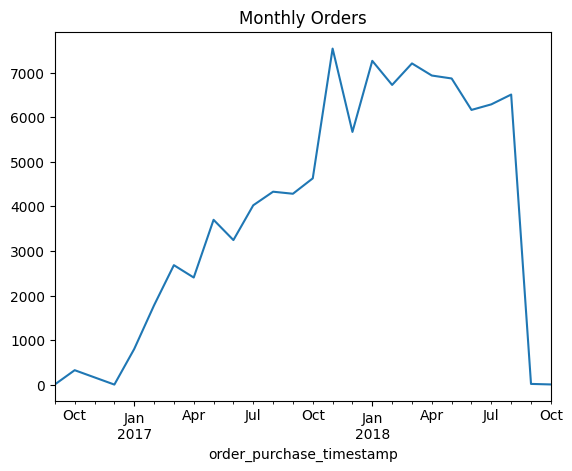

In [146]:

orders_df["order_purchase_timestamp"] = pd.to_datetime(orders_df["order_purchase_timestamp"])

orders_df.groupby(
    orders_df["order_purchase_timestamp"].dt.to_period("M")
).size().plot()
plt.title("Monthly Orders")
plt.show()


In [147]:
customer_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

<h3>Matching column names with DB</h3>

In [148]:
customer_df.rename(columns={
    'customer_zip_code_prefix': 'zip_code',
    'customer_city': 'city',
    'customer_state': 'state'
}, inplace=True)

products_df.rename(columns={
    'product_category_name': 'product_category'
}, inplace=True)

reviews_df.rename(columns={
    'review_comment_message': 'review_message'
}, inplace=True)

sellers_df.rename(columns={
    'seller_zip_code_prefix': 'seller_zip_code'
}, inplace=True)




In [155]:
customer_df.to_csv("./cleaned_ds/customer_clean.csv",index=False)
products_df.to_csv("./cleaned_ds/products_clean.csv",index=False)
reviews_df.to_csv("./cleaned_ds/reviews_clean.csv",index=False)
sellers_df.to_csv("./cleaned_ds/sellers_clean.csv", index=False)